
HIMMELBLAU FUNCTION OPTIMIZATION
f(x, y) = (x² + y - 11)² + (x + y² - 7)²

This is a simple elliptic paraboloid:
- Global minimum at (0, 0) with f = 0
- Convex (bowl-shaped)
- Perfect test case for optimization algorithms
BASIC NEWTON'S METHOD (Finding Roots)
Goal: Find (x,y) such that g(x,y) = [x² - 1, y² - 4] = [0, 0]
True roots: (±1, ±2)
Starting point: (1.000, 1.000)
------------------------------------------------------------
Iteration 0:
  (x, y) = (1.000000, 1.000000)
  g(x, y) = [-46.000000, -38.000000]
  ||g|| = 59.665736
  Δ(x, y) = (-3.897959, -6.918367)
Iteration 1:
  (x, y) = (-2.897959, -5.918367)
  g(x, y) = [149.022992, -611.933684]
  ||g|| = 629.817978
  Δ(x, y) = (-2.908130, 1.330895)
Iteration 2:
  (x, y) = (-5.806089, -4.587472)
  g(x, y) = [-404.421994, -114.934856]
  ||g|| = 420.436880
  Δ(x, y) = (1.274809, 0.825982)
Iteration 3:
  (x, y) = (-4.531280, -3.761490)
  g(x, y) = [-99.365093, -27.841189]
  ||g|| = 103.191829
  Δ(x, y) = (0.590929, 0.377548)
Iteration

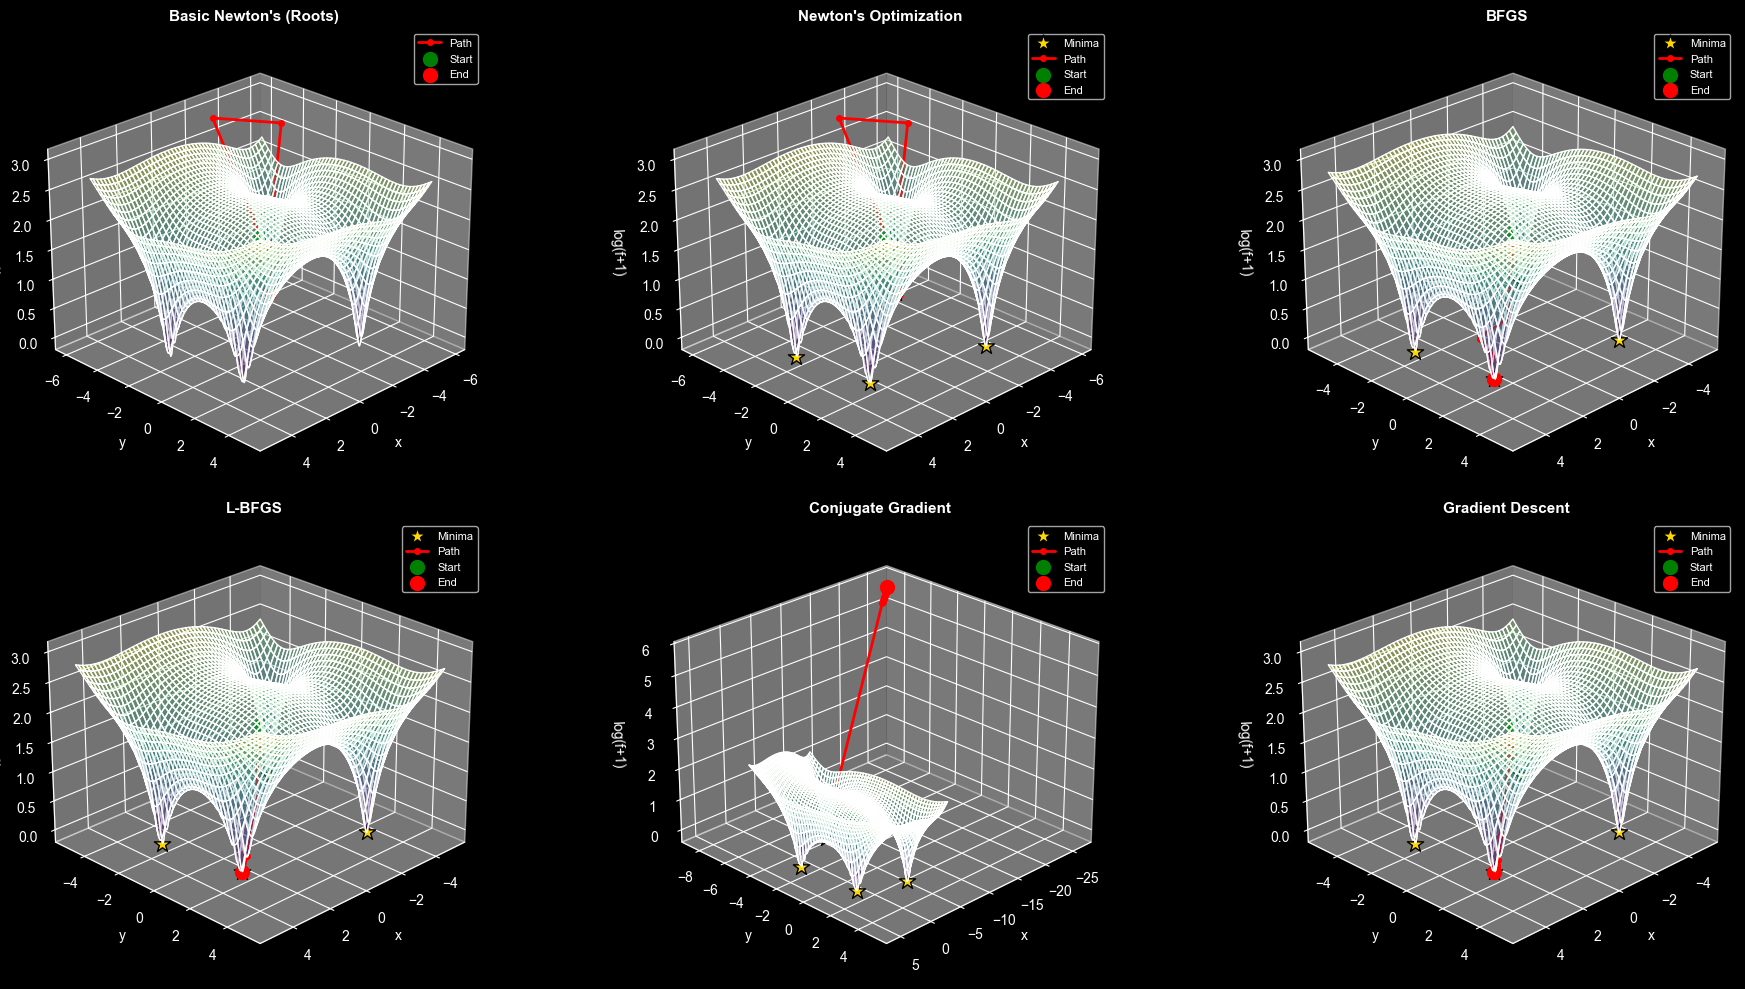

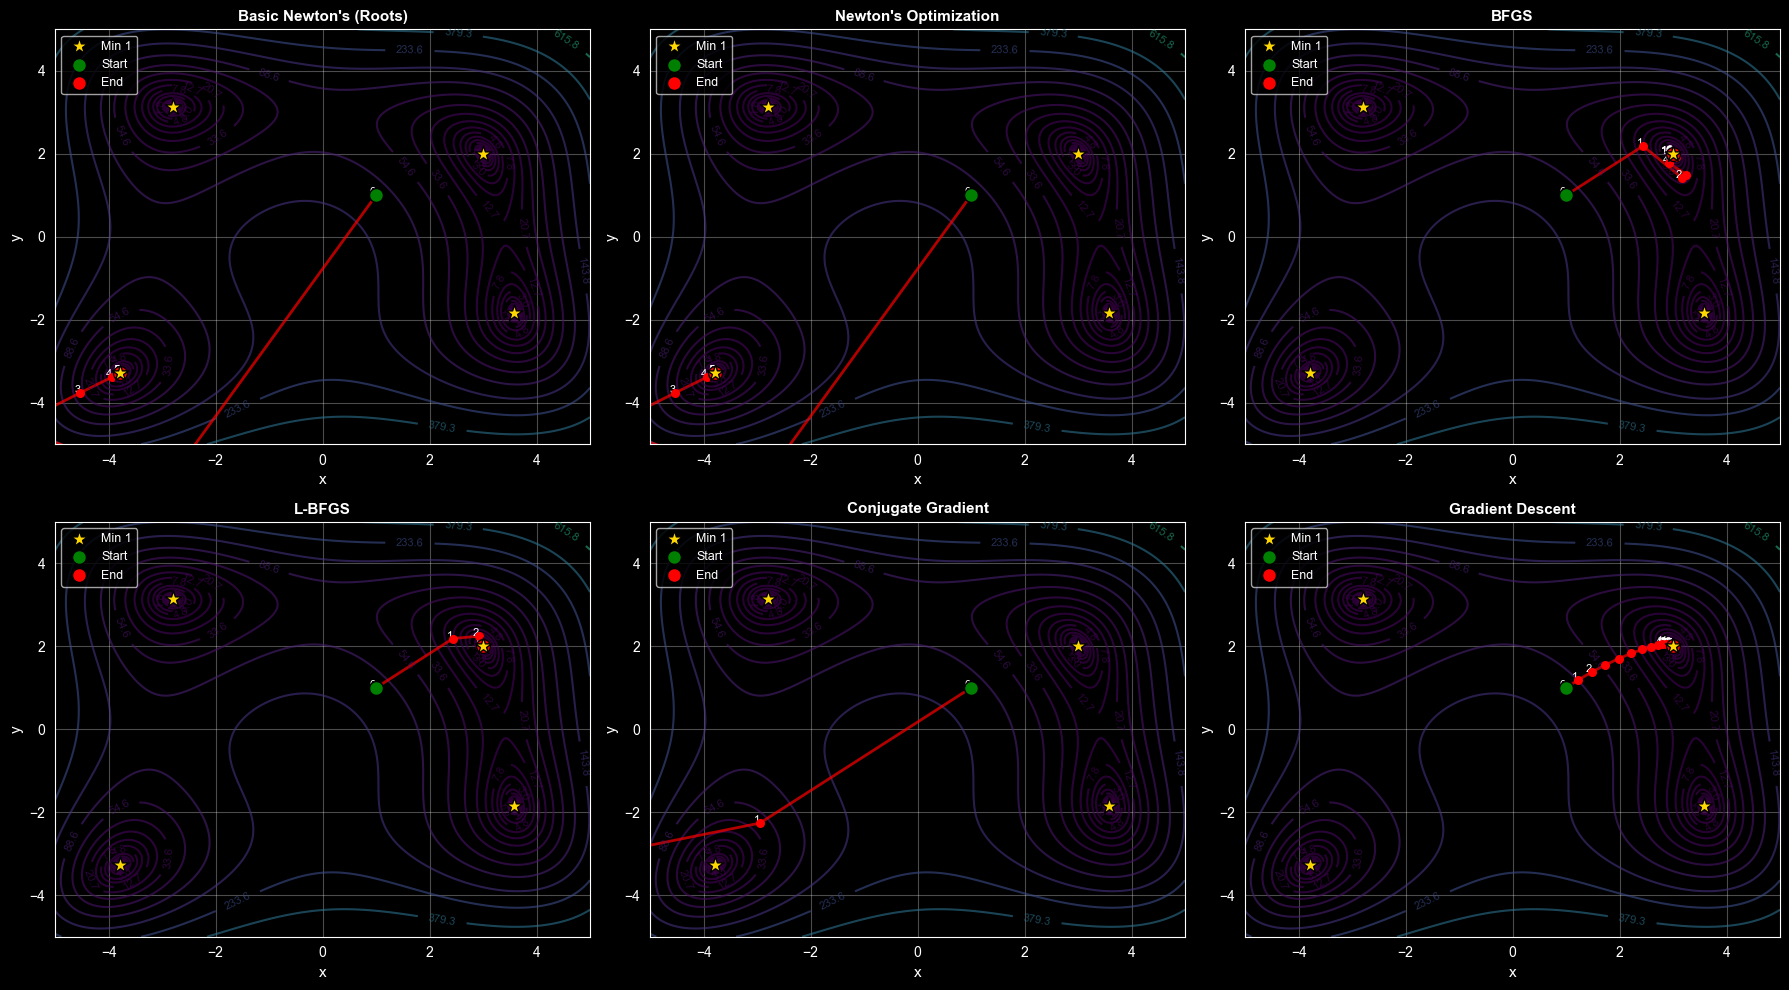

In [1]:
#!/usr/bin/env python
# coding: utf-8

# In[1]:


import numpy as np
import matplotlib.pyplot as plt
# from mpl_toolkits.mplot3d import Axes3D

# ============================================================
# HIMMELBLAU FUNCTION
# f(x, y) = (x² + y - 11)² + (x + y² - 7)²
# Four global minima at (3,2), (-2.805,3.131), (-3.779,-3.283), (3.584,-1.848)
# This is a simple quadratic - perfect for testing!
# ============================================================

def f(x, y):
    """Himmelblau function"""
    return (x**2 + y - 11)**2 + (x + y**2 - 7)**2

def gradient(x, y):
    """Gradient of Himmelblau function"""
    df_dx = 4*x*(x**2 + y - 11) + 2*(x + y**2 - 7)
    df_dy = 2*(x**2 + y - 11) + 4*y*(x + y**2 - 7)
    return np.array([df_dx, df_dy])

def hessian(x, y):
    """Hessian of Himmelblau function"""
    H11 = 12*x**2 + 4*y - 42
    H12 = 4*x + 4*y
    H21 = 4*x + 4*y
    H22 = 4*x + 12*y**2 - 26
    return np.array([[H11, H12],
                     [H21, H22]])

# For Basic Newton's, let's find roots of a related function
def g_vector(x, y):
    """Vector function for basic Newton's"""
    return gradient(x, y)  # Find critical points directly

def jacobian(x, y):
    """Jacobian of g"""
    return hessian(x, y)  # Jacobian of gradient is Hessian


# ============================================================
# 1. BASIC NEWTON'S METHOD (Finding Roots)
# ============================================================
def basic_newtons_method(x0, y0, max_iter=20, tol=1e-6, verbose=True):
    """Find roots of g(x,y) = [x² - 1, y² - 4]"""
    if verbose:
        print("="*60)
        print("BASIC NEWTON'S METHOD (Finding Roots)")
        print("="*60)
        print(f"Goal: Find (x,y) such that g(x,y) = [x² - 1, y² - 4] = [0, 0]")
        print(f"True roots: (±1, ±2)")
        print(f"Starting point: ({x0:.3f}, {y0:.3f})")
        print("-"*60)

    x, y = x0, y0
    history = [(x, y)]

    for i in range(max_iter):
        g_val = g_vector(x, y)
        J = jacobian(x, y)

        if verbose and (i % 5 == 0 or i < 5):
            print(f"Iteration {i}:")
            print(f"  (x, y) = ({x:.6f}, {y:.6f})")
            print(f"  g(x, y) = [{g_val[0]:.6f}, {g_val[1]:.6f}]")
            print(f"  ||g|| = {np.linalg.norm(g_val):.6f}")

        if np.linalg.norm(g_val) < tol:
            if verbose:
                print(f"\nConverged! Root found at ({x:.6f}, {y:.6f})")
            break

        try:
            delta = np.linalg.solve(J, -g_val)
            if verbose and (i % 5 == 0 or i < 5):
                print(f"  Δ(x, y) = ({delta[0]:.6f}, {delta[1]:.6f})")

            x, y = x + delta[0], y + delta[1]
            history.append((x, y))

        except np.linalg.LinAlgError:
            if verbose:
                print("  Singular Jacobian! Stopping.")
            break

    if verbose:
        print("-"*60)
    return history


# ============================================================
# 2. NEWTON'S METHOD FOR OPTIMIZATION
# ============================================================
def newtons_optimization(x0, y0, max_iter=20, tol=1e-6, verbose=True):
    """Find minimum of f(x,y) = x² + 2y²"""
    if verbose:
        print("="*60)
        print("NEWTON'S METHOD FOR OPTIMIZATION")
        print("="*60)
        print(f"Goal: Find minimum of f(x,y) = (x²+y-11)² + (x+y²-7)²")
        print(f"Four global minima, starting from (1, 1)")
        print(f"Starting point: ({x0:.3f}, {y0:.3f})")
        print("-"*60)

    x, y = x0, y0
    history = [(x, y)]

    for i in range(max_iter):
        grad = gradient(x, y)
        H = hessian(x, y)
        f_val = f(x, y)

        if verbose and (i % 5 == 0 or i < 5):
            print(f"Iteration {i}:")
            print(f"  (x, y) = ({x:.6f}, {y:.6f})")
            print(f"  f(x, y) = {f_val:.6f}")
            print(f"  ∇f = [{grad[0]:.6f}, {grad[1]:.6f}]")
            print(f"  ||∇f|| = {np.linalg.norm(grad):.6f}")

        if np.linalg.norm(grad) < tol:
            if verbose:
                print(f"\nIteration {i}:")
                print(f"  (x, y) = ({x:.6f}, {y:.6f})")
                print(f"  f(x, y) = {f_val:.6f}")
                print(f"Converged! Minimum found at ({x:.6f}, {y:.6f})")
            break

        try:
            delta = np.linalg.solve(H, -grad)
            if verbose and (i % 5 == 0 or i < 5):
                print(f"  Δ(x, y) = ({delta[0]:.6f}, {delta[1]:.6f})")

            x, y = x + delta[0], y + delta[1]
            history.append((x, y))

        except np.linalg.LinAlgError:
            if verbose:
                print("  Singular Hessian! Stopping.")
            break

    if verbose:
        print("-"*60)
    return history


# ============================================================
# 3. BFGS (QUASI-NEWTON METHOD)
# ============================================================
def line_search_wolfe(x, p, grad, c1=1e-4, c2=0.9, max_iter=20):
    """Backtracking line search with Wolfe conditions"""
    alpha = 1.0
    f_x = f(x[0], x[1])
    grad_dot_p = grad @ p

    for _ in range(max_iter):
        x_new = x + alpha * p
        f_new = f(x_new[0], x_new[1])

        # Armijo condition
        if f_new <= f_x + c1 * alpha * grad_dot_p:
            grad_new = gradient(x_new[0], x_new[1])
            if abs(grad_new @ p) <= -c2 * grad_dot_p:
                return alpha
            elif grad_new @ p >= 0:
                alpha *= 0.5
            else:
                return alpha
        else:
            alpha *= 0.5

    return alpha

def bfgs_method(x0, y0, max_iter=100, tol=1e-6, verbose=True):
    """BFGS quasi-Newton optimization"""
    if verbose:
        print("="*60)
        print("BFGS (QUASI-NEWTON METHOD)")
        print("="*60)
        print(f"Goal: Find minimum using Hessian approximation")
        print(f"Starting point: ({x0:.3f}, {y0:.3f})")
        print("-"*60)

    x = np.array([x0, y0])
    history = [tuple(x)]
    H = np.eye(2)  # Initial inverse Hessian approximation
    grad = gradient(x[0], x[1])

    for k in range(max_iter):
        f_val = f(x[0], x[1])
        grad_norm = np.linalg.norm(grad)

        if verbose and (k % 10 == 0 or k < 5):
            print(f"Iteration {k}:")
            print(f"  (x, y) = ({x[0]:.6f}, {x[1]:.6f})")
            print(f"  f(x, y) = {f_val:.6f}")
            print(f"  ||∇f|| = {grad_norm:.6f}")

        if grad_norm < tol:
            if verbose:
                print(f"\nIteration {k}:")
                print(f"  (x, y) = ({x[0]:.6f}, {x[1]:.6f})")
                print(f"  f(x, y) = {f_val:.6f}")
                print(f"Converged! Minimum found at ({x[0]:.6f}, {x[1]:.6f})")
            break

        # Search direction
        p = -H @ grad

        # Line search
        alpha = line_search_wolfe(x, p, grad)

        if verbose and (k % 10 == 0 or k < 5):
            print(f"  Step size α = {alpha:.6f}")

        # Update position
        x_new = x + alpha * p
        grad_new = gradient(x_new[0], x_new[1])

        # BFGS update
        s = x_new - x
        y = grad_new - grad
        rho = y @ s

        if rho > 1e-10:
            rho_inv = 1.0 / rho
            I = np.eye(2)
            A = I - rho_inv * np.outer(s, y)
            H = A.T @ H @ A + rho_inv * np.outer(s, s)

        x = x_new
        grad = grad_new
        history.append(tuple(x))

    if verbose:
        print("-"*60)
    return history


# ============================================================
# 3b. L-BFGS (LIMITED-MEMORY BFGS)
# ============================================================
def lbfgs_method(x0, y0, m=5, max_iter=100, tol=1e-6, verbose=True):
    """L-BFGS optimization using two-loop recursion"""
    if verbose:
        print("="*60)
        print("L-BFGS (LIMITED-MEMORY BFGS)")
        print("="*60)
        print(f"Goal: Find minimum using limited-memory Hessian approximation")
        print(f"Memory parameter m = {m} (stored vector pairs)")
        print(f"Starting point: ({x0:.3f}, {y0:.3f})")
        print("-"*60)

    x = np.array([x0, y0])
    history = [tuple(x)]
    grad = gradient(x[0], x[1])

    # Storage for last m (s, y, rho) pairs
    s_list = []
    y_list = []
    rho_list = []

    for k in range(max_iter):
        f_val = f(x[0], x[1])
        grad_norm = np.linalg.norm(grad)

        if verbose and (k % 10 == 0 or k < 5):
            print(f"Iteration {k}:")
            print(f"  (x, y) = ({x[0]:.6f}, {x[1]:.6f})")
            print(f"  f(x, y) = {f_val:.6f}")
            print(f"  ||∇f|| = {grad_norm:.6f}")

        if grad_norm < tol:
            if verbose:
                print(f"\nIteration {k}:")
                print(f"  (x, y) = ({x[0]:.6f}, {x[1]:.6f})")
                print(f"  f(x, y) = {f_val:.6f}")
                print(f"Converged! Minimum found at ({x[0]:.6f}, {x[1]:.6f})")
            break

        # L-BFGS two-loop recursion to compute search direction
        q = grad.copy()
        n_stored = len(s_list)
        alpha_list = np.zeros(n_stored)

        # First loop (backward)
        for i in range(n_stored - 1, -1, -1):
            alpha_list[i] = rho_list[i] * (s_list[i] @ q)
            q = q - alpha_list[i] * y_list[i]

        # Initial Hessian scaling
        if n_stored > 0:
            gamma = (s_list[-1] @ y_list[-1]) / (y_list[-1] @ y_list[-1])
            r = gamma * q
        else:
            r = q.copy()

        # Second loop (forward)
        for i in range(n_stored):
            beta = rho_list[i] * (y_list[i] @ r)
            r = r + (alpha_list[i] - beta) * s_list[i]

        p = -r  # Search direction

        # Line search
        step = line_search_wolfe(x, p, grad)

        if verbose and (k % 10 == 0 or k < 5):
            print(f"  Step size α = {step:.6f}")

        # Update position
        x_new = x + step * p
        grad_new = gradient(x_new[0], x_new[1])

        # Store s and y vectors
        s = x_new - x
        y_vec = grad_new - grad
        rho = y_vec @ s

        if rho > 1e-10:
            if len(s_list) >= m:
                s_list.pop(0)
                y_list.pop(0)
                rho_list.pop(0)
            s_list.append(s)
            y_list.append(y_vec)
            rho_list.append(1.0 / rho)

        x = x_new
        grad = grad_new
        history.append(tuple(x))

    if verbose:
        print("-"*60)
    return history


# ============================================================
# 4. GRADIENT DESCENT
# ============================================================
def gradient_descent(x0, y0, alpha=0.005, max_iter=5000, tol=1e-6, verbose=True):
    """Find minimum using gradient descent"""
    if verbose:
        print("="*60)
        print("GRADIENT DESCENT")
        print("="*60)
        print(f"Goal: Find minimum of f(x,y) = (x²+y-11)² + (x+y²-7)²")
        print(f"Four global minima, starting from (1, 1)")
        print(f"Starting point: ({x0:.3f}, {y0:.3f})")
        print(f"Learning rate α = {alpha}")
        print("-"*60)

    x, y = x0, y0
    history = [(x, y)]

    for i in range(max_iter):
        grad = gradient(x, y)
        f_val = f(x, y)

        if verbose and (i % 100 == 0 or i < 10):
            print(f"Iteration {i}:")
            print(f"  (x, y) = ({x:.6f}, {y:.6f})")
            print(f"  f(x, y) = {f_val:.6f}")
            print(f"  ∇f = [{grad[0]:.6f}, {grad[1]:.6f}]")
            print(f"  ||∇f|| = {np.linalg.norm(grad):.6f}")

        if np.linalg.norm(grad) < tol:
            if verbose:
                print(f"\nIteration {i}:")
                print(f"  (x, y) = ({x:.6f}, {y:.6f})")
                print(f"  f(x, y) = {f_val:.6f}")
                print(f"Converged! Minimum found at ({x:.6f}, {y:.6f})")
            break

        x, y = x - alpha * grad[0], y - alpha * grad[1]
        history.append((x, y))

    if verbose:
        print("-"*60)
    return history


# ============================================================
# 5. CONJUGATE GRADIENT
# ============================================================
def conjugate_gradient(x0, y0, max_iter=20, tol=1e-6, verbose=True):
    """Find minimum using conjugate gradient method"""
    if verbose:
        print("="*60)
        print("CONJUGATE GRADIENT")
        print("="*60)
        print(f"Goal: Find minimum of f(x,y) = (x²+y-11)² + (x+y²-7)²")
        print(f"Four global minima, starting from (1, 1)")
        print(f"Starting point: ({x0:.3f}, {y0:.3f})")
        print("-"*60)

    x, y = x0, y0
    history = [(x, y)]
    grad = gradient(x, y)
    d = -grad

    for i in range(max_iter):
        f_val = f(x, y)
        grad_norm = np.linalg.norm(grad)

        if verbose and (i % 5 == 0 or i < 5):
            print(f"Iteration {i}:")
            print(f"  (x, y) = ({x:.6f}, {y:.6f})")
            print(f"  f(x, y) = {f_val:.6f}")
            print(f"  ||∇f|| = {grad_norm:.6f}")

        if grad_norm < tol:
            if verbose:
                print(f"\nIteration {i}:")
                print(f"  (x, y) = ({x:.6f}, {y:.6f})")
                print(f"  f(x, y) = {f_val:.6f}")
                print(f"Converged! Minimum found at ({x:.6f}, {y:.6f})")
            break

        # Optimal step size for quadratic
        H = hessian(x, y)
        Hd = H @ d
        alpha = (grad @ grad) / (d @ Hd)

        if verbose and (i % 5 == 0 or i < 5):
            print(f"  Step size α = {alpha:.6f}")

        x_new = x + alpha * d[0]
        y_new = y + alpha * d[1]
        grad_new = gradient(x_new, y_new)

        # Fletcher-Reeves formula
        beta = (grad_new @ grad_new) / (grad @ grad)
        d = -grad_new + beta * d

        x, y = x_new, y_new
        grad = grad_new
        history.append((x, y))

    if verbose:
        print("-"*60)
    return history


# ============================================================
# VISUALIZATION
# ============================================================
def plot_results(history_basic, history_newton, history_bfgs, history_lbfgs, history_cg, history_gd, save_dir='.'):
    """Plot the optimization paths on the paraboloid surface"""

    x_range = np.linspace(-5, 5, 200)
    y_range = np.linspace(-5, 5, 200)
    X, Y = np.meshgrid(x_range, y_range)
    Z = f(X, Y)
    Z_log = np.log10(Z + 1)

    fig = plt.figure(figsize=(20, 10))

    titles = ["Basic Newton's (Roots)", "Newton's Optimization", 'BFGS', 'L-BFGS', 'Conjugate Gradient', 'Gradient Descent']
    histories = [history_basic, history_newton, history_bfgs, history_lbfgs, history_cg, history_gd]

    for idx, (title, history) in enumerate(zip(titles, histories)):
        ax = fig.add_subplot(2, 3, idx+1, projection='3d')
        ax.plot_surface(X, Y, Z_log, alpha=0.3, cmap='viridis')

        if idx > 0:
            # Mark all four minima in 3D
            minima = [(3.0, 2.0), (-2.805118, 3.131312), (-3.779310, -3.283186), (3.584428, -1.848126)]
            for i, (mx, my) in enumerate(minima):
                label = 'Minima' if i == 0 else ''
                mz = np.log10(f(mx, my) + 1)
                ax.scatter([mx], [my], [mz], color='gold', s=150, marker='*',
                          label=label, edgecolors='black', zorder=10)

        if history:
            xs = [p[0] for p in history]
            ys = [p[1] for p in history]
            zs = [np.log10(f(x, y) + 1) for x, y in history]

            ax.plot(xs, ys, zs, 'ro-', linewidth=2, markersize=4, label='Path')
            ax.scatter([xs[0]], [ys[0]], [zs[0]], color='green', s=100, label='Start')
            ax.scatter([xs[-1]], [ys[-1]], [zs[-1]], color='red', s=100, label='End')

        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.set_zlabel('log(f+1)')
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.legend(fontsize=8)
        ax.view_init(elev=25, azim=45)

    plt.tight_layout()
    plt.savefig(f'{save_dir}/himmelblau_bfgs_3d.png', dpi=150, bbox_inches='tight')
    print(f"\n3D plot saved to: {save_dir}/himmelblau_bfgs_3d.png")

    plot_contours(history_basic, history_newton, history_bfgs, history_lbfgs, history_cg, history_gd, save_dir)


def plot_contours(history_basic, history_newton, history_bfgs, history_lbfgs, history_cg, history_gd, save_dir='.'):
    """Plot contour view from above"""

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    x_range = np.linspace(-5, 5, 200)
    y_range = np.linspace(-5, 5, 200)
    X, Y = np.meshgrid(x_range, y_range)
    Z = f(X, Y)

    titles = ["Basic Newton's (Roots)", "Newton's Optimization", 'BFGS', 'L-BFGS', 'Conjugate Gradient', 'Gradient Descent']
    histories = [history_basic, history_newton, history_bfgs, history_lbfgs, history_cg, history_gd]

    for ax, title, history in zip(axes[:6], titles, histories):
        levels = np.logspace(-1, 3, 20)
        contour = ax.contour(X, Y, Z, levels=levels, cmap='viridis', alpha=0.6)
        ax.clabel(contour, inline=True, fontsize=8)

        # Mark all four minima
        minima = [(3.0, 2.0), (-2.805118, 3.131312), (-3.779310, -3.283186), (3.584428, -1.848126)]
        for i, (mx, my) in enumerate(minima):
            label = f'Min {i+1}' if i == 0 else ''
            ax.scatter([mx], [my], color='gold', s=150, marker='*',
                      zorder=7, label=label, edgecolors='black')

        if history:
            xs = [p[0] for p in history]
            ys = [p[1] for p in history]

            ax.plot(xs, ys, 'r-', linewidth=2, alpha=0.7)
            ax.scatter(xs, ys, c='red', s=30, zorder=5)
            ax.scatter([xs[0]], [ys[0]], color='green', s=100,
                      zorder=6, label='Start', edgecolors='black')
            ax.scatter([xs[-1]], [ys[-1]], color='red', s=100,
                      zorder=6, label='End', edgecolors='black')

            for i, (x, y) in enumerate(history):
                if i % max(1, len(history)//10) == 0 or i < 3:
                    ax.annotate(f'{i}', (x, y), fontsize=8, ha='right')

        ax.set_xlabel('x', fontsize=11)
        ax.set_ylabel('y', fontsize=11)
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9)
        ax.set_xlim(-5, 5)
        ax.set_ylim(-5, 5)

    plt.tight_layout()
    plt.savefig(f'{save_dir}/himmelblau_bfgs_contours.png', dpi=150, bbox_inches='tight')
    print(f"Contour plot saved to: {save_dir}/himmelblau_bfgs_contours.png\n")


# ============================================================
# MAIN EXECUTION
# ============================================================
if __name__ == "__main__":
    print("\n" + "="*60)
    print("HIMMELBLAU FUNCTION OPTIMIZATION")
    print("f(x, y) = (x² + y - 11)² + (x + y² - 7)²")
    print("="*60)
    print("\nThis is a simple elliptic paraboloid:")
    print("- Global minimum at (0, 0) with f = 0")
    print("- Convex (bowl-shaped)")
    print("- Perfect test case for optimization algorithms")
    print("="*60)

    x0, y0 = 1.0, 1.0

    history_basic = basic_newtons_method(x0, y0, max_iter=20)
    print("\n")
    history_newton = newtons_optimization(x0, y0, max_iter=20)
    print("\n")
    history_bfgs = bfgs_method(x0, y0, max_iter=100)
    print("\n")
    history_lbfgs = lbfgs_method(x0, y0, m=5, max_iter=100)
    print("\n")
    history_cg = conjugate_gradient(x0, y0, max_iter=20)
    print("\n")
    history_gd = gradient_descent(x0, y0, alpha=0.005, max_iter=5000)

    plot_results(history_basic, history_newton, history_bfgs, history_lbfgs, history_cg, history_gd, save_dir='.')

    print("\n" + "="*60)
    print("SUMMARY")
    print("="*60)
    print(f"Basic Newton's:        {len(history_basic)} iterations")
    print(f"Newton's Optimization: {len(history_newton)} iterations")
    print(f"BFGS:                  {len(history_bfgs)} iterations")
    print(f"L-BFGS:                {len(history_lbfgs)} iterations")
    print(f"Conjugate Gradient:    {len(history_cg)} iterations")
    print(f"Gradient Descent:      {len(history_gd)} iterations")
    print("="*60)

    print("\nFINAL POINTS:")
    print(f"Basic Newton's:        ({history_basic[-1][0]:.6f}, {history_basic[-1][1]:.6f}), f = {f(*history_basic[-1]):.6f}")
    print(f"Newton's Optimization: ({history_newton[-1][0]:.6f}, {history_newton[-1][1]:.6f}), f = {f(*history_newton[-1]):.6f}")
    print(f"BFGS:                  ({history_bfgs[-1][0]:.6f}, {history_bfgs[-1][1]:.6f}), f = {f(*history_bfgs[-1]):.6f}")
    print(f"L-BFGS:                ({history_lbfgs[-1][0]:.6f}, {history_lbfgs[-1][1]:.6f}), f = {f(*history_lbfgs[-1]):.6f}")
    print(f"Conjugate Gradient:    ({history_cg[-1][0]:.6f}, {history_cg[-1][1]:.6f}), f = {f(*history_cg[-1]):.6f}")
    print(f"Gradient Descent:      ({history_gd[-1][0]:.6f}, {history_gd[-1][1]:.6f}), f = {f(*history_gd[-1]):.6f}")
    print(f"True Minima: (3,2), (-2.805,3.131), (-3.779,-3.283), (3.584,-1.848)")
    print("="*60)

    print("\nINTERPRETATION:")
    print("For the Himmelblau function with four global minima:")
    print("- Different methods may find different minima (basin of attraction)")
    print("- Newton's optimization uses exact Hessian for fast convergence")
    print("- BFGS approximates Hessian from gradient information")
    print("- L-BFGS matches BFGS with only m stored vector pairs (O(n) memory)")
    print("- Conjugate gradient uses smart directions")
    print("- Gradient descent is slow but robust")
    print("- Basic Newton's finds critical points (roots of gradient)")
    print("="*60)


# In[ ]: